Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

Load Dataset

In [ ]:
df = pd.read_csv('/content/sales_dataset.csv')

df.head()

,Quantity,Discount,Profit,Order_Month,Order_Year,Sales
0,5,0.10,50,6,2017,200
1,3,0.00,20,3,2016,120
2,10,0.20,100,11,2018,400
3,2,0.05,10,1,2015,80
4,7,0.15,70,9,2019,300


Explore Data

In [ ]:
print(df.shape)
df.info()
df.describe()

(15, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Quantity     15 non-null     int64  
 1   Discount     15 non-null     float64
 2   Profit       15 non-null     int64  
 3   Order_Month  15 non-null     int64  
 4   Order_Year   15 non-null     int64  
 5   Sales        15 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 852.0 bytes


,Quantity,Discount,Profit,Order_Month,Order_Year,Sales
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,5.200000,0.110000,52.333333,6.400000,2017.266667,225.333333
std,2.704494,0.096732,33.851918,3.397478,1.624221,122.350005
min,1.000000,0.000000,5.000000,1.000000,2015.000000,50.000000
25%,3.000000,0.025000,22.500000,3.500000,2016.000000,125.000000
50%,5.000000,0.100000,55.000000,6.000000,2017.000000,230.000000
75%,7.000000,0.175000,75.000000,9.000000,2018.500000,310.000000
max,10.000000,0.300000,110.000000,12.000000,2020.000000,450.000000


Handle Missing Values

In [ ]:
# Check missing values
print(df.isnull().sum())

# Fill numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

Quantity       0
Discount       0
Profit         0
Order_Month    0
Order_Year     0
Sales          0
dtype: int64


Define Features & Target

In [ ]:
X = df[['Quantity', 'Discount', 'Profit', 'Order_Month', 'Order_Year']]
y = df['Sales']

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
      )


Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Models

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

Evaluate Models

In [ ]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "MAE", "RMSE"])
results_df

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.987588,13.013686,15.302488
1,Decision Tree,0.890459,40.000000,45.460606
2,Random Forest,0.796589,53.166667,61.949146


Visualization (Model Comparison)

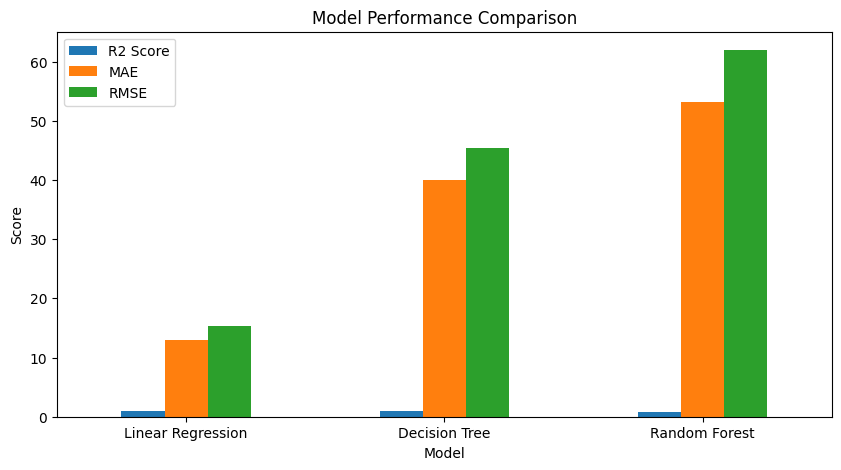

In [ ]:
results_df.set_index("Model").plot(kind='bar', figsize=(10,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

Actual vs Predicted (Best Model)

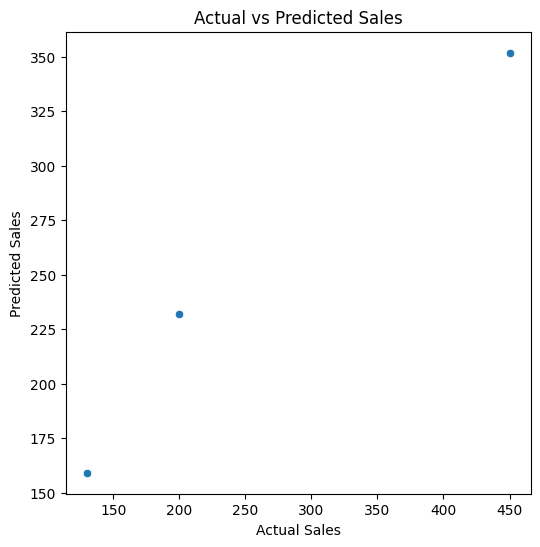

In [ ]:
best_model = trained_models["Random Forest"]

y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

Predict New Value

In [ ]:
sample = X_test[0].reshape(1, -1)
prediction = best_model.predict(sample)

print("Predicted Sales:", prediction[0])

Predicted Sales: 351.9


In [ ]:
!pip install streamlit

In [ ]:
import pickle

# save model + scaler
pickle.dump(best_model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle

# Load model and scaler
model = pickle.load(open('model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

st.title("📊 Sales Prediction Dashboard")

st.write("Enter input values to predict Sales")

# Inputs (adjust based on your dataset)
quantity = st.number_input("Quantity", min_value=1, max_value=100, value=5)
discount = st.slider("Discount", 0.0, 1.0, 0.1)
profit = st.number_input("Profit", value=50.0)
order_month = st.slider("Order Month", 1, 12, 6)
order_year = st.slider("Order Year", 2015, 2020, 2017)

# Prepare input
input_data = np.array([[quantity, discount, profit, order_month, order_year]])

# Scale input
input_scaled = scaler.transform(input_data)

# Predict
prediction = model.predict(input_scaled)

st.subheader("💰 Predicted Sales:")
st.success(f"{prediction[0]:.2f}")

Overwriting app.py


In [ ]:
!ls

app.py	model.pkl  sales_dataset.csv  sample_data  scaler.pkl  Superstore.csv


In [ ]:
!rm model.pkl scaler.pkl

In [ ]:
X = df.drop('Sales', axis=1)
y = df['Sales']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestRegressor()
model.fit(X_train, y_train)

import pickle
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle

# Load model and scaler
model = pickle.load(open('model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

st.title("📊 Sales Prediction Dashboard")
st.write("Enter details to predict Sales")

# Inputs
quantity = st.number_input("Quantity", min_value=1, max_value=20, value=5)
discount = st.slider("Discount", 0.0, 1.0, 0.1)
profit = st.number_input("Profit", value=50.0)
order_month = st.slider("Order Month", 1, 12, 6)
order_year = st.slider("Order Year", 2015, 2020, 2017)

# Create input array
input_data = np.array([[quantity, discount, profit, order_month, order_year]])

# Scale input
input_scaled = scaler.transform(input_data)

# Prediction button
if st.button("Predict Sales"):
  prediction = model.predict(input_scaled)
  st.success(f"Predicted Sales: {prediction[0]:.2f}")

Overwriting app.py


In [ ]:
!pip install pyngrok
from pyngrok import ngrok

ngrok.set_auth_token("3CfzvzjDqw4QfMsKtWeHgzbhFvL_4C9vGRBef262mK5njjA5S")

In [ ]:
!streamlit run app.py &>/dev/null &
ngrok.connect(8501)

<NgrokTunnel: "https://repressed-mouth-tamper.ngrok-free.dev" -> "http://localhost:8501">